# De la media a la simulación: generando escenarios de viento con estadística aplicada

En este notebook vamos a construir, **paso a paso y explicando cada cosa desde cero**, una
herramienta real de ingeniería: un generador de **escenarios de velocidad de viento** (útil,
por ejemplo, para dimensionar un aerogenerador o simular la producción de un parque eólico).

La idea central es mostrar que conceptos que ya conocemos —**media**, **desviación estándar**,
**percentiles**, **histogramas**— no son solo ejercicios de clase: son las piezas con las que
se construyen herramientas de simulación que se usan en proyectos reales

No vamos a partir del código final (que es largo y abstracto). Vamos a construirlo **en capas**,
con muchas gráficas en el camino, para que cada paso se entienda de forma visual e intuitiva.

## Contenido

1. Fundamentos: ¿qué es una variable aleatoria, una PDF, una CDF y un percentil?
2. Los datos: viento Bogotá D.C. de 2015 a 2024 (10 años)
3. Estadística descriptiva básica
4. Estadística condicionada (el viento según la hora y el mes)
5. Funciones de probabilidad para modelar el viento (a fondo, con muchas gráficas)
6. La idea clave: escenarios malo/medio/bueno con media ± desviación estándar
7. Simulación de Montecarlo: de probabilidades a valores concretos
8. Ensamblando todo en una función
9. Radiografía completa: la PDF de cada hora del día
10. Visualizando el resultado final
11. Cierre y ejercicios

Al final vas a tener el mismo tipo de función que se usó en la tesis, pero entendiendo
*por qué* existe cada línea de código.


In [2]:
# Librerías que vamos a usar durante todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Para que los resultados aleatorios sean reproducibles (todos obtenemos lo mismo)
np.random.seed(42)

# Un poco de estilo para que los gráficos se vean bien
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "font.size": 11})


## 1. Fundamentos: variables aleatorias, PDF, CDF y percentiles

Antes de tocar un solo dato de viento, aseguremos las bases con ejemplos sencillos
(dados y números simulados). Todo lo que veamos aquí lo vamos a usar después con el viento.

### 1.1 ¿Qué es una variable aleatoria?

Una **variable aleatoria** es, en la práctica, cualquier cantidad cuyo valor no conocemos con
certeza de antemano, pero de la cual sí conocemos qué tan probable es cada resultado posible.
El ejemplo más clásico: **lanzar un dado**. No sabemos qué número va a salir, pero sabemos
que cada cara tiene 1/6 de probabilidad.

Vamos a simular 1000 lanzamientos de un dado y comparar la frecuencia observada de cada cara
contra la probabilidad teórica (1/6 para cada una).


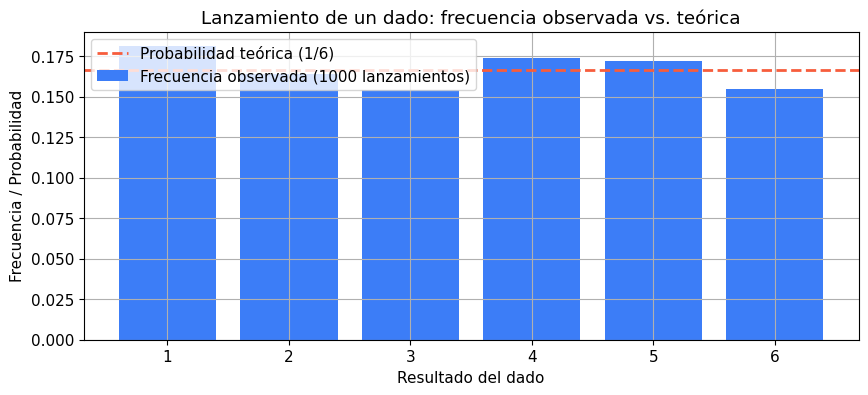

In [2]:
lanzamientos = np.random.randint(1, 7, size=1000)  # 1000 lanzamientos de un dado (valores 1 a 6)

valores, conteos = np.unique(lanzamientos, return_counts=True)
frecuencias = conteos / len(lanzamientos)

plt.bar(valores, frecuencias, color="#3C7DF7", label="Frecuencia observada (1000 lanzamientos)")
plt.axhline(1/6, color="#F75D3C", linestyle="--", linewidth=2, label="Probabilidad teórica (1/6)")
plt.title("Lanzamiento de un dado: frecuencia observada vs. teórica")
plt.xlabel("Resultado del dado")
plt.ylabel("Frecuencia / Probabilidad")
plt.legend()
plt.show()


Con muchos lanzamientos, la frecuencia observada (barras azules) se acerca cada vez
más a la probabilidad teórica (línea naranja). Esto se llama informalmente **ley de los
grandes números**: entre más repeticiones, más se parece lo observado a lo teórico. Esta idea
va a ser clave más adelante, cuando generemos miles de valores simulados de viento.

El dado es una variable **discreta** (solo toma valores 1, 2, 3, 4, 5 o 6). El viento, en
cambio, es una variable **continua** (puede tomar cualquier valor decimal: 3.42 m/s, 7.81 m/s,
etc.). Para variables continuas usamos otro tipo de herramienta: la **función de densidad de
probabilidad (PDF)**. Vamos a construir la intuición con un ejemplo simulado.


### 1.2 Del histograma a la curva continua: ¿qué es realmente un histograma?

Simulemos 2000 números aleatorios de una distribución conocida (la normal, la típica "campana
de Gauss") y miremos qué pasa si dibujamos su histograma con distintas cantidades de barras
(*bins*).


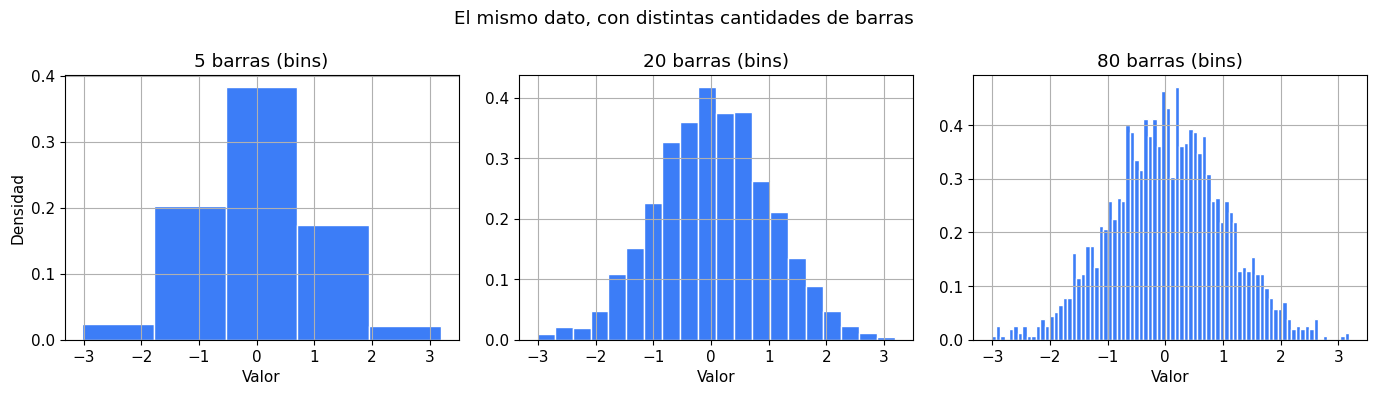

In [3]:
datos_ejemplo = np.random.normal(loc=0, scale=1, size=2000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, bins in zip(axes, [5, 20, 80]):
    ax.hist(datos_ejemplo, bins=bins, density=True, color="#3C7DF7", edgecolor="white")
    ax.set_title(f"{bins} barras (bins)")
    ax.set_xlabel("Valor")
axes[0].set_ylabel("Densidad")
plt.suptitle("El mismo dato, con distintas cantidades de barras")
plt.tight_layout()
plt.show()


- Con **muy pocas barras** (izquierda) perdemos detalle: se ve demasiado "en bloques".
- Con **demasiadas barras** (derecha) el histograma se vuelve ruidoso: cada barra tiene pocos
  datos y el patrón general se pierde entre el ruido.
- Un número intermedio (centro) suele mostrar mejor la forma real de los datos.

Esto es justo el problema que resuelve una **distribución de probabilidad teórica**: en vez
de depender de cuántas barras dibujamos, describimos los datos con una **fórmula matemática
continua** (una curva suave) que no depende de esa elección arbitraria.

### 1.3 ¿Los datos se parecen más a la "verdad" entre más datos tengamos?

Repitamos el histograma anterior, pero ahora variando **cuántos datos** simulamos (no cuántas
barras usamos), y comparémoslo contra la curva teórica real de la normal.


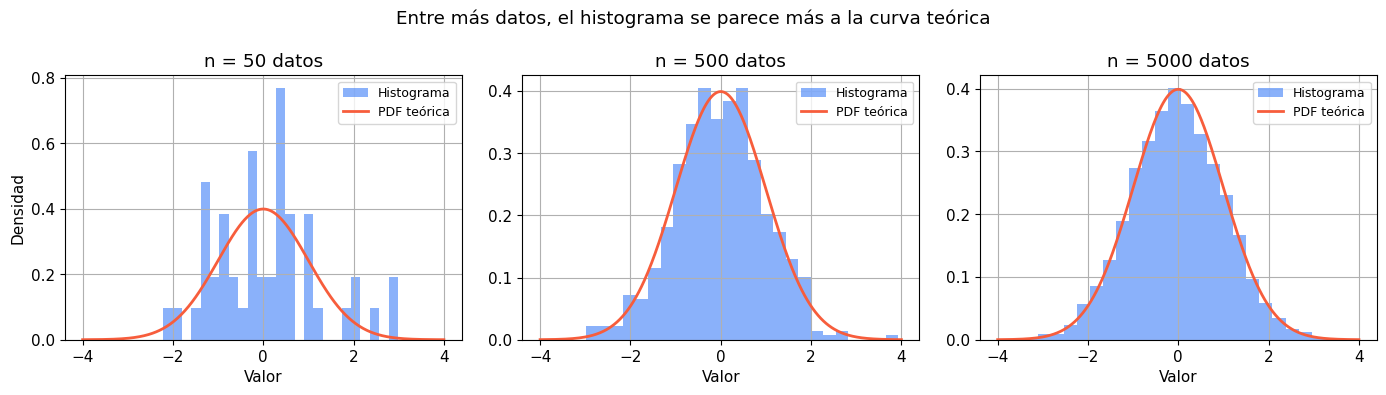

In [4]:
tamaños_muestra = [50, 500, 5000]
x_normal = np.linspace(-4, 4, 400)
pdf_normal_teorica = stats.norm.pdf(x_normal, loc=0, scale=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, n in zip(axes, tamaños_muestra):
    muestra = np.random.normal(loc=0, scale=1, size=n)
    ax.hist(muestra, bins=25, density=True, color="#3C7DF7", alpha=0.6, label="Histograma")
    ax.plot(x_normal, pdf_normal_teorica, color="#F75D3C", linewidth=2, label="PDF teórica")
    ax.set_title(f"n = {n} datos")
    ax.set_xlabel("Valor")
    ax.legend(fontsize=9)
axes[0].set_ylabel("Densidad")
plt.suptitle("Entre más datos, el histograma se parece más a la curva teórica")
plt.tight_layout()
plt.show()


Con pocos datos (n=50) el histograma es irregular. Con muchos datos (n=5000) el
histograma prácticamente calca la curva teórica. **Esta es la razón por la que "ajustar una
distribución" es útil**: la curva teórica es una versión limpia e ideal de lo que el
histograma nos muestra de forma ruidosa.

### 1.4 La función de densidad de probabilidad (PDF)

La curva naranja de arriba es una **PDF**. Su propiedad más importante: el **área bajo toda
la curva es exactamente 1** (porque la probabilidad de "algún" resultado siempre es del
100%). El área bajo la curva **entre dos puntos** nos da la probabilidad de que la variable
caiga en ese rango.


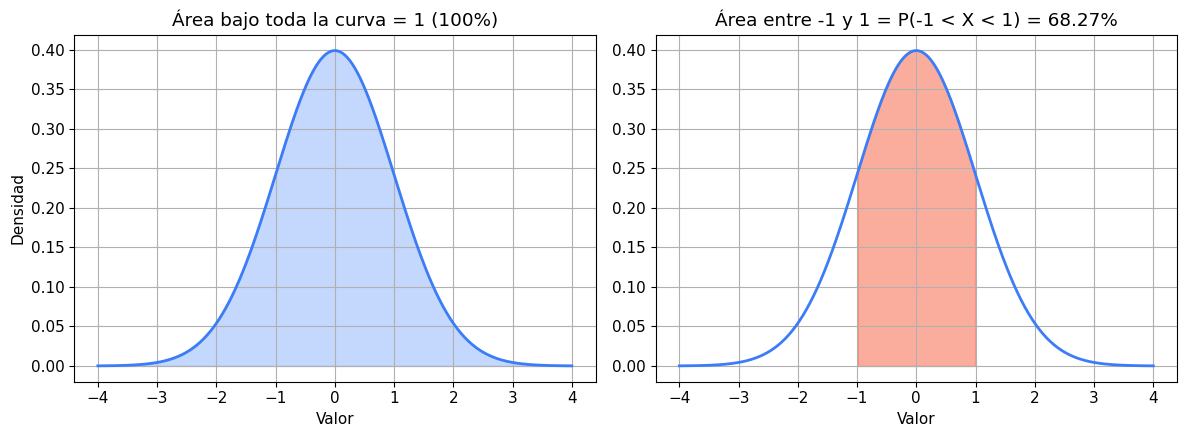

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: el área bajo TODA la curva es 1
axes[0].plot(x_normal, pdf_normal_teorica, color="#3C7DF7", linewidth=2)
axes[0].fill_between(x_normal, pdf_normal_teorica, color="#3C7DF7", alpha=0.3)
axes[0].set_title("Área bajo toda la curva = 1 (100%)")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Densidad")

# Panel 2: el área entre -1 y 1 es la probabilidad de que la variable caiga ahí
mascara_rango = (x_normal >= -1) & (x_normal <= 1)
axes[1].plot(x_normal, pdf_normal_teorica, color="#3C7DF7", linewidth=2)
axes[1].fill_between(x_normal, pdf_normal_teorica, where=mascara_rango, color="#F75D3C", alpha=0.5)
prob_rango = stats.norm.cdf(1) - stats.norm.cdf(-1)
axes[1].set_title(f"Área entre -1 y 1 = P(-1 < X < 1) = {prob_rango:.2%}")
axes[1].set_xlabel("Valor")

plt.tight_layout()
plt.show()


¡Interesante! El área sombreada entre -1 y 1 (es decir, entre **media - 1 desviación
estándar** y **media + 1 desviación estándar**, ya que aquí la media es 0 y la desviación
estándar es 1) equivale a **68.27%** de probabilidad. Esta es la famosa **regla empírica** que
seguramente ya conoces de estadística básica. Guarda esta idea: en la sección 6 la vamos a
usar para clasificar el viento en escenarios.

### 1.5 La función de distribución acumulada (CDF)

La **CDF** responde la pregunta: *"¿cuál es la probabilidad de que la variable sea menor o
igual a cierto valor `x`?"*. Mientras la PDF es la curva de densidad, la CDF es su versión
"acumulada" — siempre empieza en 0 (a la izquierda) y termina en 1 (a la derecha), subiendo
todo el tiempo.


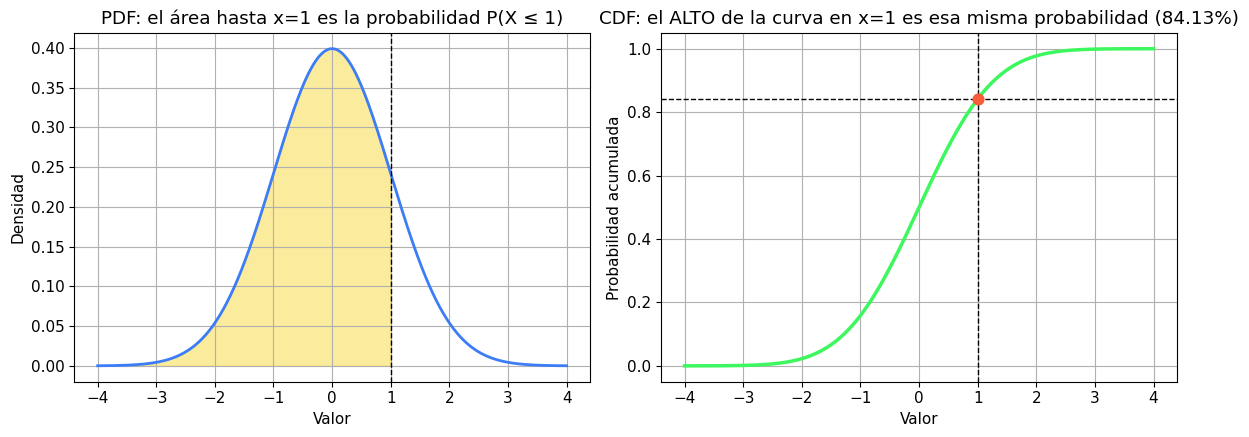

In [6]:
cdf_normal_teorica = stats.norm.cdf(x_normal, loc=0, scale=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x_normal, pdf_normal_teorica, color="#3C7DF7", linewidth=2)
axes[0].fill_between(x_normal, pdf_normal_teorica, where=(x_normal <= 1), color="#F7D93C", alpha=0.5)
axes[0].axvline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("PDF: el área hasta x=1 es la probabilidad P(X ≤ 1)")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Densidad")

axes[1].plot(x_normal, cdf_normal_teorica, color="#3CF75D", linewidth=2.5)
axes[1].axvline(1, color="black", linestyle="--", linewidth=1)
axes[1].axhline(stats.norm.cdf(1), color="black", linestyle="--", linewidth=1)
axes[1].scatter([1], [stats.norm.cdf(1)], color="#F75D3C", zorder=5, s=60)
axes[1].set_title(f"CDF: el ALTO de la curva en x=1 es esa misma probabilidad ({stats.norm.cdf(1):.2%})")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Probabilidad acumulada")

plt.tight_layout()
plt.show()


Este es el punto más importante de toda esta sección: **el área bajo la PDF hasta un
punto `x`, es exactamente la altura de la CDF en ese mismo punto `x`.** Por eso en la práctica
casi nunca calculamos áreas "a mano" — simplemente le preguntamos a la CDF (`dist.cdf(x)` en
Python) y ella nos da la probabilidad directamente.

### 1.6 Percentiles: leyendo la CDF al revés

Un **percentil** es la pregunta inversa a la CDF: en vez de "¿qué probabilidad hay de estar
por debajo de `x`?", preguntamos "¿qué valor `x` deja exactamente el `p`% de los datos por
debajo?". Por ejemplo, el percentil 90 es el valor por debajo del cual está el 90% de los
datos.


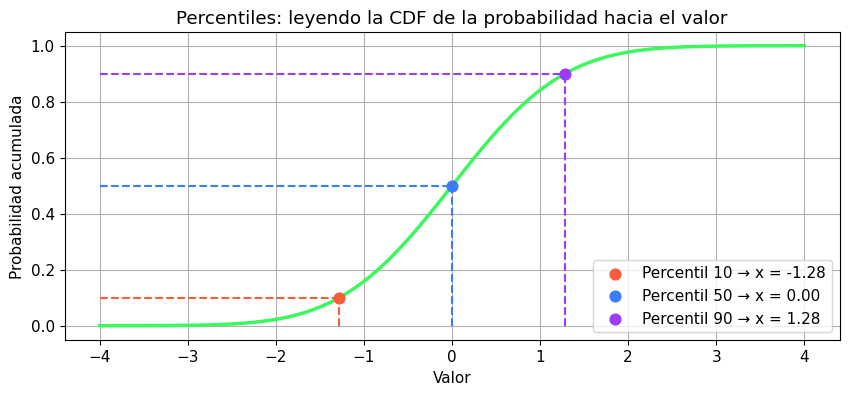

In [7]:
percentiles_ejemplo = [10, 50, 90]
valores_percentiles = stats.norm.ppf(np.array(percentiles_ejemplo) / 100)

plt.plot(x_normal, cdf_normal_teorica, color="#3CF75D", linewidth=2.5)
colores_pct = ["#F75D3C", "#3C7DF7", "#9B3CF7"]
for p, val, c in zip(percentiles_ejemplo, valores_percentiles, colores_pct):
    plt.plot([val, val], [0, p/100], color=c, linestyle="--")
    plt.plot([x_normal.min(), val], [p/100, p/100], color=c, linestyle="--")
    plt.scatter([val], [p/100], color=c, zorder=5, s=60, label=f"Percentil {p} → x = {val:.2f}")

plt.title("Percentiles: leyendo la CDF de la probabilidad hacia el valor")
plt.xlabel("Valor")
plt.ylabel("Probabilidad acumulada")
plt.legend()
plt.show()


Con esto ya tenemos las cuatro piezas fundamentales que vamos a reutilizar todo el
notebook: **variable aleatoria, PDF, CDF y percentil**. Ahora sí, vamos a aplicarlas a un
problema real: el viento.


## 2. Los datos: viento sintético para 10 años

Usaremos la API de la NASA para obtener los datos de 2015 a 2024 de velocidad del viento. 10 años para Bogotá

Para simular el viento usamos la distribución **Weibull**, que es la distribución que la
literatura de energía eólica usa casi universalmente para modelar velocidades de viento
(el viento nunca es negativo y su histograma normalmente es asimétrico, con una cola larga
hacia la derecha). En la sección 5 vamos a explicar esto con calma; por ahora, solo generamos
los datos con los que vamos a trabajar todo el notebook.


In [3]:
import requests

lat = 4.7110
lon = -74.0721

url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start=20150101"
    f"&end=20241231"
    "&format=JSON"
)

response = requests.get(url)
data = response.json()

viento = data["properties"]["parameter"]["WS2M"]

fechas = pd.to_datetime(list(viento.keys()), format="%Y%m%d%H")
velocidad_viento = list(viento.values())

df = pd.DataFrame({
    "Year": fechas.year,
    "Month": fechas.month,
    "Day": fechas.day,
    "Hour": fechas.hour,
    "WindSpeed": velocidad_viento,
}, index=fechas)

print(df.shape)
print(df.head().to_string())


(87672, 5)
                     Year  Month  Day  Hour  WindSpeed
2015-01-01 00:00:00  2015      1    1     0       0.94
2015-01-01 01:00:00  2015      1    1     1       1.03
2015-01-01 02:00:00  2015      1    1     2       1.08
2015-01-01 03:00:00  2015      1    1     3       1.16
2015-01-01 04:00:00  2015      1    1     4       1.20


Antes de calcular cualquier estadística, siempre es buena práctica **mirar los datos
crudos**. Grafiquemos las primeras dos semanas de enero, hora a hora.


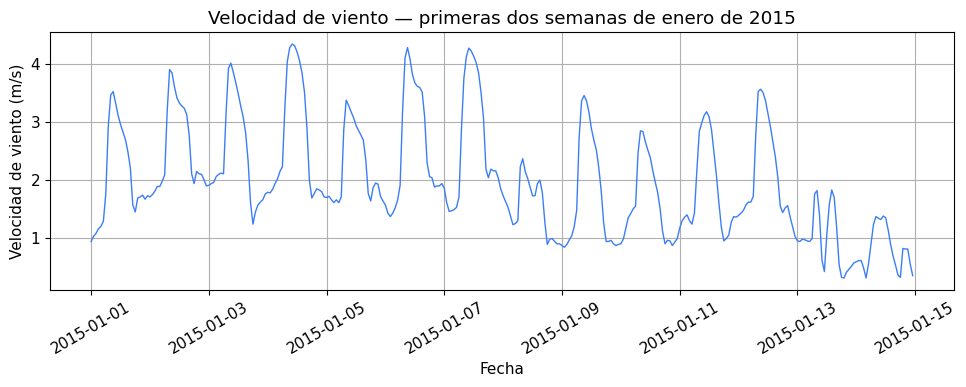

In [7]:
primeras_dos_semanas = df.loc["2015-01-01":"2015-01-14"]

plt.plot(primeras_dos_semanas.index, primeras_dos_semanas["WindSpeed"], color="#3C7DF7", linewidth=1)
plt.title("Velocidad de viento — primeras dos semanas de enero de 2015")
plt.xlabel("Fecha")
plt.ylabel("Velocidad de viento (m/s)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Se nota que el viento sube y baja todo el tiempo, sin un patrón obvio a simple vista.
Es exactamente para "domesticar" este tipo de ruido que existe la estadística: convertir
observaciones sueltas en resúmenes y modelos que sí podemos interpretar y usar.


## 3. Estadística descriptiva básica: ¿cómo es "el viento" en general?

Empecemos con la pregunta más simple posible: **¿cómo se comporta la velocidad del viento en
todo el año?** Usamos las medidas que ya conocen:

- **Media**: el valor "típico" (promedio).
- **Mediana**: el valor que deja la mitad de los datos abajo y la mitad arriba (más robusta a
  valores extremos que la media).
- **Desviación estándar**: qué tan dispersos están los datos alrededor de la media.
- **Percentiles**: por ejemplo, el percentil 90 nos dice el valor por debajo del cual está el
  90% de las observaciones.


In [4]:
col = "WindSpeed"

media = df[col].mean()
mediana = df[col].median()
desv_std = df[col].std()
p10, p50, p90 = np.percentile(df[col], [10, 50, 90])

print(f"Media:              {media:.2f} m/s")
print(f"Mediana:            {mediana:.2f} m/s")
print(f"Desviación estándar:{desv_std:6.2f} m/s")
print(f"Percentil 10:       {p10:.2f} m/s")
print(f"Percentil 50:       {p50:.2f} m/s")
print(f"Percentil 90:       {p90:.2f} m/s")


Media:              1.14 m/s
Mediana:            0.92 m/s
Desviación estándar:  0.75 m/s
Percentil 10:       0.41 m/s
Percentil 50:       0.92 m/s
Percentil 90:       2.20 m/s


Visualicemos estas mismas cifras sobre el histograma completo del año, para que se
vean como lo que son: puntos de referencia sobre la distribución real de los datos.


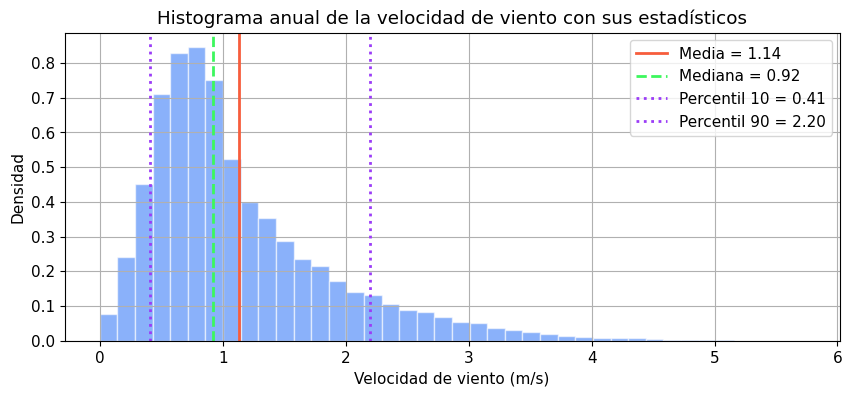

In [5]:
plt.hist(df[col], bins=40, density=True, color="#3C7DF7", alpha=0.6, edgecolor="white")
plt.axvline(media, color="#F75D3C", linewidth=2, label=f"Media = {media:.2f}")
plt.axvline(mediana, color="#3CF75D", linewidth=2, linestyle="--", label=f"Mediana = {mediana:.2f}")
plt.axvline(p10, color="#9B3CF7", linewidth=2, linestyle=":", label=f"Percentil 10 = {p10:.2f}")
plt.axvline(p90, color="#9B3CF7", linewidth=2, linestyle=":", label=f"Percentil 90 = {p90:.2f}")
plt.title("Histograma anual de la velocidad de viento con sus estadísticos")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.legend()
plt.show()


Nota que la media queda un poco a la derecha de la mediana: eso es una pista visual de
que la distribución **no es simétrica** (tiene cola hacia la derecha, hacia valores altos de
viento). Guardemos también esta observación para la sección 5.

Otra forma muy común de resumir visualmente estas mismas cinco cifras (mínimo, percentil 25,
mediana, percentil 75 y máximo) es el **diagrama de caja (boxplot)**.


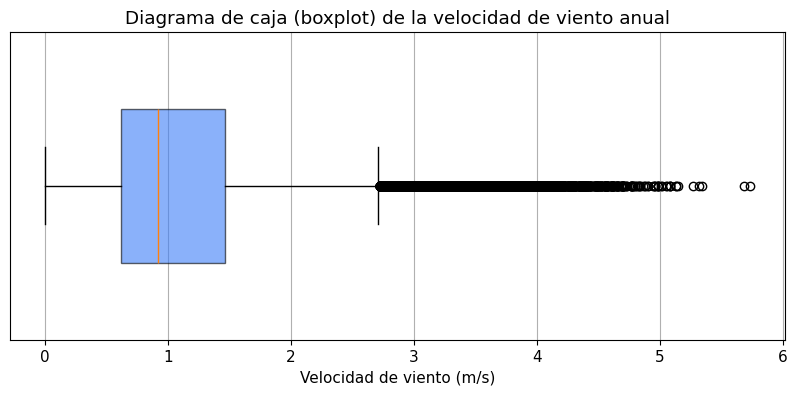

In [6]:
plt.boxplot(df[col], vert=False, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor="#3C7DF7", alpha=0.6))
plt.title("Diagrama de caja (boxplot) de la velocidad de viento anual")
plt.xlabel("Velocidad de viento (m/s)")
plt.yticks([])
plt.show()


La "caja" central contiene el 50% de los datos (entre el percentil 25 y el 75), la
línea dentro de la caja es la mediana, y los "bigotes" se extienden hasta los valores más
extremos que no se consideran atípicos. Los puntos sueltos (si los hay) son valores atípicos.


## 4. Estadística "condicionada": el viento según la hora y el mes

Una sola media para todo el año **esconde** mucha información: no es lo mismo el viento a las
3am en julio que a las 6pm en enero. Calculemos la media **por mes** y la media **por hora del
día** por separado (esto es lo mismo que ya sabes hacer con `groupby` + `mean`, solo que ahora
la pregunta es más interesante), y también miremos la dispersión con boxplots.


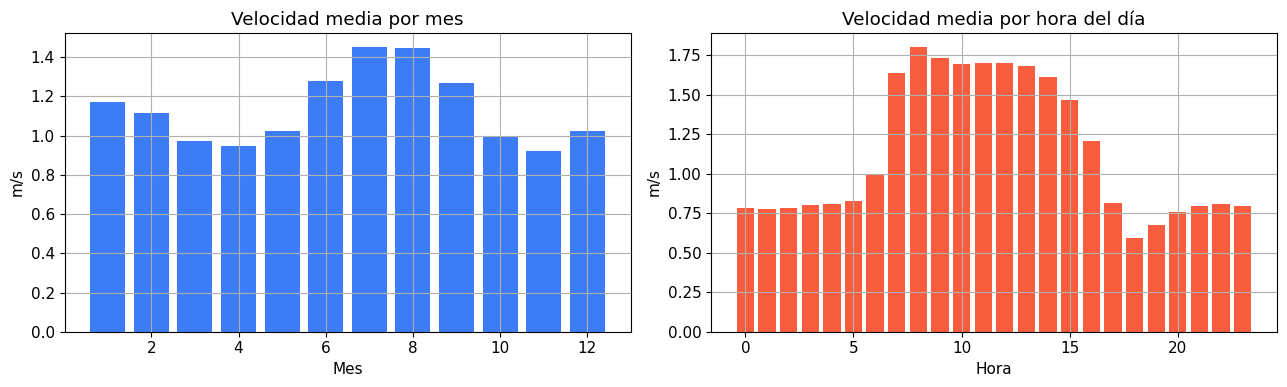

In [11]:
media_por_mes = df.groupby("Month")[col].mean()
media_por_hora = df.groupby("Hour")[col].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(media_por_mes.index, media_por_mes.values, color="#3C7DF7")
axes[0].set_title("Velocidad media por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("m/s")

axes[1].bar(media_por_hora.index, media_por_hora.values, color="#F75D3C")
axes[1].set_title("Velocidad media por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("m/s")

plt.tight_layout()
plt.show()


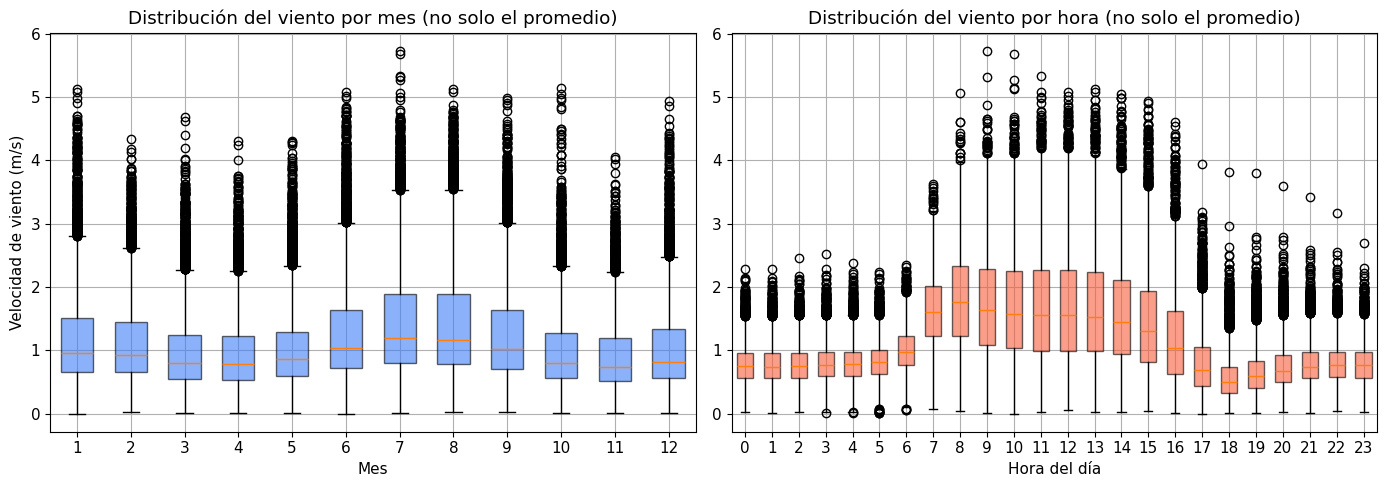

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos_por_mes = [df.loc[df.Month == m, col].to_numpy() for m in range(1, 13)]
axes[0].boxplot(datos_por_mes, positions=range(1, 13), widths=0.6, patch_artist=True,
                boxprops=dict(facecolor="#3C7DF7", alpha=0.6))
axes[0].set_title("Distribución del viento por mes (no solo el promedio)")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Velocidad de viento (m/s)")

datos_por_hora = [df.loc[df.Hour == h, col].to_numpy() for h in range(0, 24)]
axes[1].boxplot(datos_por_hora, positions=range(0, 24), widths=0.6, patch_artist=True,
                boxprops=dict(facecolor="#F75D3C", alpha=0.6))
axes[1].set_title("Distribución del viento por hora (no solo el promedio)")
axes[1].set_xlabel("Hora del día")

plt.tight_layout()
plt.show()


Los boxplots nos muestran algo que las barras de promedio no: **la dispersión también
cambia** según el mes y la hora, no solo el promedio. Esto va a ser importante más adelante,
porque significa que cada combinación de mes y hora necesita **su propio análisis
estadístico**, no uno genérico para todo el año.

Para ver ambos efectos (mes y hora) **al mismo tiempo**, un mapa de calor (heatmap) es ideal:
cada celda representa la velocidad media del viento para una combinación específica de mes y
hora.


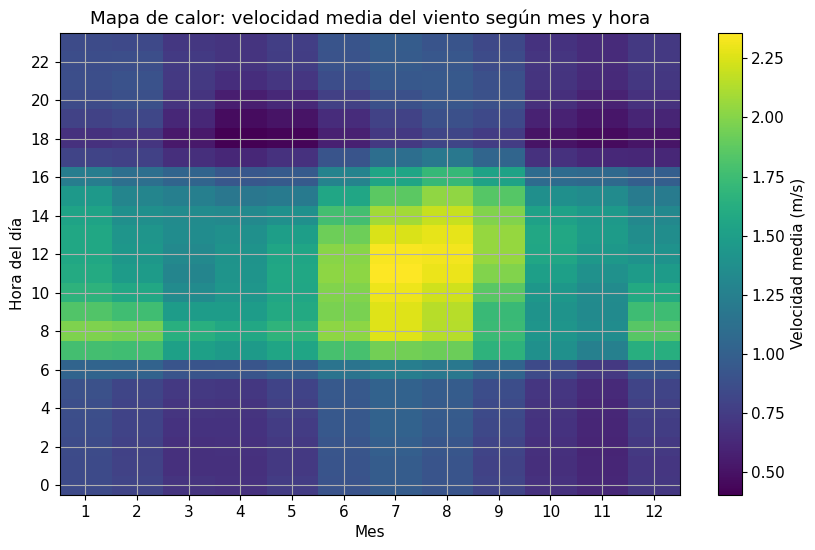

In [13]:
tabla_mes_hora = df.pivot_table(index="Hour", columns="Month", values=col, aggfunc="mean")

plt.figure(figsize=(10, 6))
plt.imshow(tabla_mes_hora, aspect="auto", cmap="viridis", origin="lower")
plt.colorbar(label="Velocidad media (m/s)")
plt.title("Mapa de calor: velocidad media del viento según mes y hora")
plt.xlabel("Mes")
plt.ylabel("Hora del día")
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.yticks(ticks=range(0, 24, 2), labels=range(0, 24, 2))
plt.show()


**Conclusión práctica:** si queremos simular el viento de forma realista, no podemos
usar una sola distribución para todo el año — necesitamos **una distribución distinta para
cada combinación de mes y hora** (12 meses × 24 horas = 288 "grupos"). Esa es exactamente la
lógica que vamos a construir en el resto del notebook.


## 5. Funciones de probabilidad para modelar el viento (a fondo)

Esta es la sección más importante del notebook. Vamos a tomar **un solo grupo** de datos
(enero, mediodía) y explicar con muchas gráficas todo lo que hay detrás de "ajustar una
distribución de probabilidad".


In [8]:
df.to_excel("velocidad_viento.xlsx", index=False)

Observaciones disponibles para mes=1, hora=12: 310
Media del grupo: 1.57 m/s | Desv. estándar del grupo: 0.95 m/s


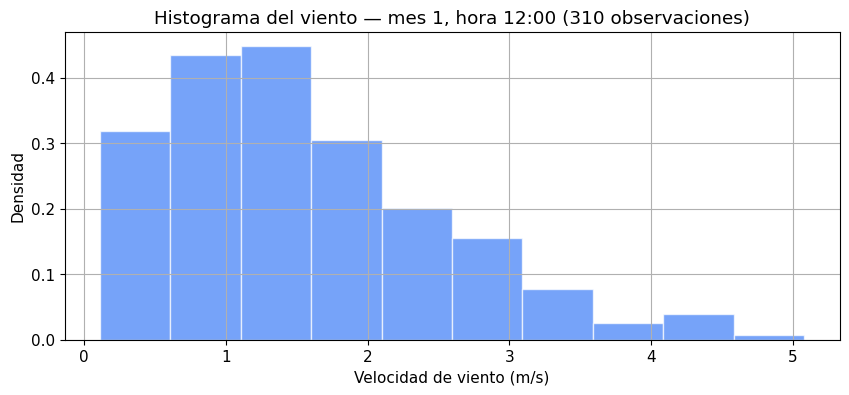

In [11]:
mes_ejemplo, hora_ejemplo = 1, 12  # enero, mediodía

datos_grupo = df.loc[(df.Month == mes_ejemplo) & (df.Hour == hora_ejemplo), col].to_numpy()
print(f"Observaciones disponibles para mes={mes_ejemplo}, hora={hora_ejemplo}: {len(datos_grupo)}")
print(f"Media del grupo: {datos_grupo.mean():.2f} m/s | Desv. estándar del grupo: {datos_grupo.std():.2f} m/s")

plt.hist(datos_grupo, bins=10, density=True, color="#3C7DF7", alpha=0.7, edgecolor="white")
plt.title(f"Histograma del viento — mes {mes_ejemplo}, hora {hora_ejemplo}:00 ({len(datos_grupo)} observaciones)")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.show()


### 5.1 ¿Por qué no usar la distribución Normal?

La distribución más famosa es la **Normal** (la campana de Gauss), pero **no** es una buena
opción para el viento, por dos razones que podemos ver directamente en una gráfica:

1. La Normal es **simétrica**, pero el viento tiene cola hacia la derecha (valores altos poco
   frecuentes pero posibles).
2. La Normal permite **valores negativos**, pero el viento nunca puede ser negativo.

Comparemos una Normal (con la misma media y desviación estándar que nuestros datos) contra el
histograma real.


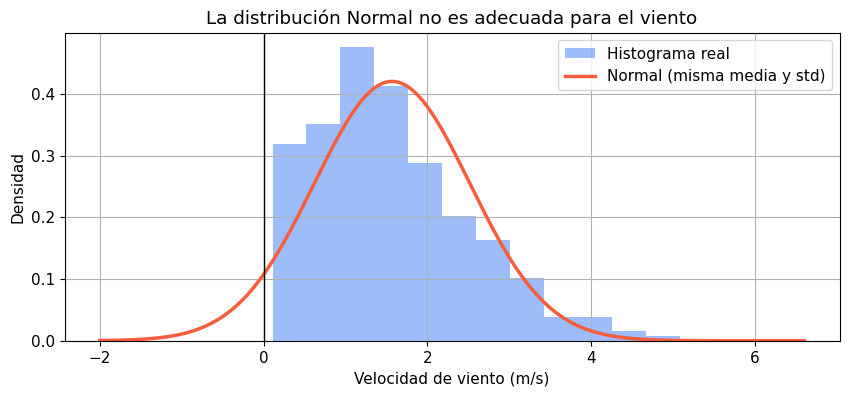

In [16]:
media_grupo, std_grupo = datos_grupo.mean(), datos_grupo.std()
x_rango = np.linspace(-2, datos_grupo.max() * 1.3, 500)
pdf_normal_comparacion = stats.norm.pdf(x_rango, loc=media_grupo, scale=std_grupo)

plt.hist(datos_grupo, bins=12, density=True, color="#3C7DF7", alpha=0.5, label="Histograma real")
plt.plot(x_rango, pdf_normal_comparacion, color="#F75D3C", linewidth=2.5, label="Normal (misma media y std)")
plt.axvline(0, color="black", linewidth=1)
plt.title("La distribución Normal no es adecuada para el viento")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.legend()
plt.show()


Nota cómo la curva naranja se extiende hacia valores **negativos** (imposibles para el
viento) y no logra capturar bien la forma asimétrica del histograma. Por eso, para variables
físicas que son siempre positivas y con cola a la derecha (viento, lluvia, tiempos de espera,
etc.), se usan otras familias de distribuciones — en el caso del viento, la más usada es la
**Weibull**.

### 5.2 La distribución Weibull y sus dos parámetros

La Weibull tiene dos parámetros que controlan completamente su forma:

- **Forma (k, *shape*):** controla qué tan asimétrica es la curva.
  - k = 1 → decae como una exponencial.
  - k ≈ 2 → forma parecida a la distribución Rayleigh (muy común para viento).
  - k grande (>3) → se vuelve más simétrica, parecida a una campana.
- **Escala (λ, *scale*):** estira o comprime la curva horizontalmente — controla la
  "magnitud típica" de los valores, sin cambiar tanto su forma.

Veamos el efecto de cada parámetro por separado.


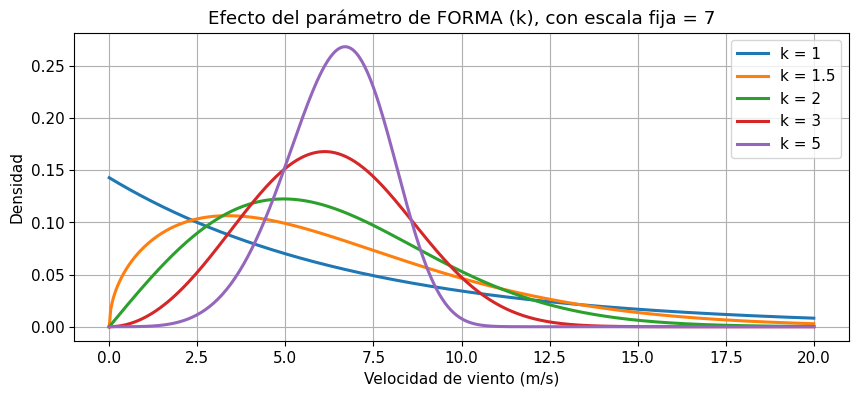

In [17]:
x_weibull = np.linspace(0, 20, 500)

plt.figure()
for k in [1, 1.5, 2, 3, 5]:
    plt.plot(x_weibull, stats.weibull_min.pdf(x_weibull, c=k, scale=7), linewidth=2.2, label=f"k = {k}")
plt.title("Efecto del parámetro de FORMA (k), con escala fija = 7")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.legend()
plt.show()


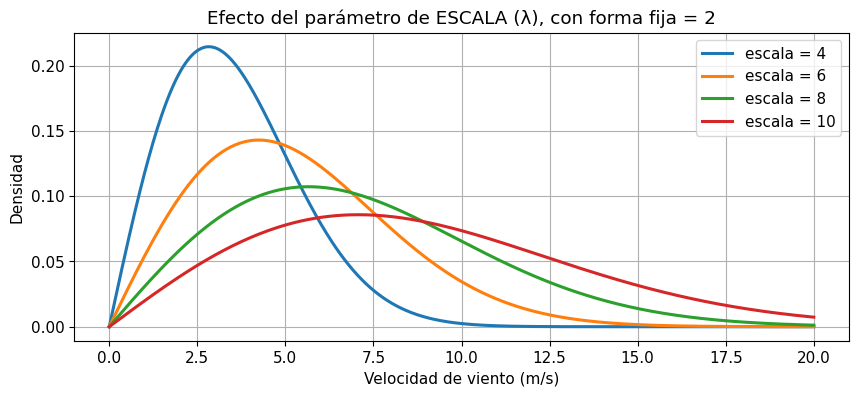

In [18]:
plt.figure()
for escala_ejemplo in [4, 6, 8, 10]:
    plt.plot(x_weibull, stats.weibull_min.pdf(x_weibull, c=2, scale=escala_ejemplo), linewidth=2.2,
             label=f"escala = {escala_ejemplo}")
plt.title("Efecto del parámetro de ESCALA (λ), con forma fija = 2")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.legend()
plt.show()


Con estas dos gráficas ya podemos "leer" la familia Weibull: la forma decide qué tan
inclinada/asimétrica es la curva, y la escala decide qué tan a la derecha (valores más altos)
se ubica. **Ajustar una distribución es, ni más ni menos, que encontrar la combinación exacta
de forma y escala que mejor reproduce nuestros datos observados.**

### 5.3 ¿Qué significa "ajustar" (fit)? Una intuición antes del código

Antes de dejar que `scipy` calcule los parámetros automáticamente, veamos manualmente qué
significa "un buen ajuste" contra "un mal ajuste", probando 3 combinaciones de parámetros a
ojo sobre el mismo histograma.


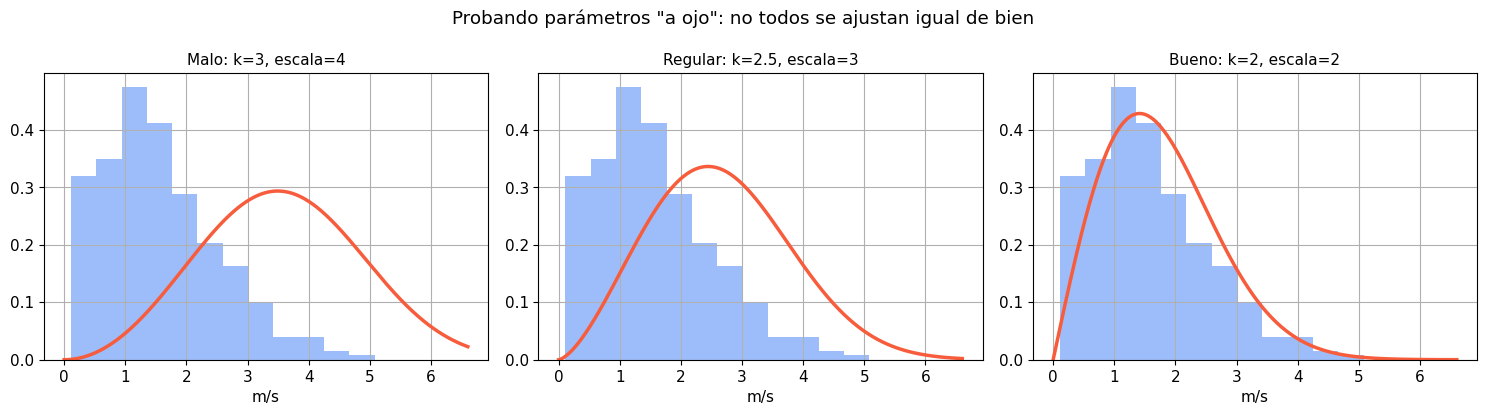

In [26]:
candidatos = {
    "Malo: k=3, escala=4":   dict(c=3, scale=4),
    "Regular: k=2.5, escala=3": dict(c=2.5, scale=3),
    "Bueno: k=2, escala=2":  dict(c=2, scale=2),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
x_cand = np.linspace(0, datos_grupo.max() * 1.3, 500)
for ax, (nombre, params) in zip(axes, candidatos.items()):
    ax.hist(datos_grupo, bins=12, density=True, color="#3C7DF7", alpha=0.5)
    ax.plot(x_cand, stats.weibull_min.pdf(x_cand, **params), color="#F75D3C", linewidth=2.5)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("m/s")
plt.suptitle("Probando parámetros \"a ojo\": no todos se ajustan igual de bien")
plt.tight_layout()
plt.show()


Se nota a simple vista cuál combinación se parece más al histograma. En vez de probar
combinaciones a mano, `scipy.stats` usa un método llamado **máxima verosimilitud**, que —dicho
de forma simple— **busca automáticamente los parámetros que hacen más probable haber
observado exactamente estos datos**. Es la versión sistemática y precisa de lo que acabamos de
hacer a ojo.

### 5.4 El ajuste real con `scipy`


Parámetros ajustados -> forma: 1.58, ubicación: 0.09, escala: 1.65
Media de la distribución ajustada: 1.57 m/s
Desv. estándar de la distribución ajustada: 0.96 m/s


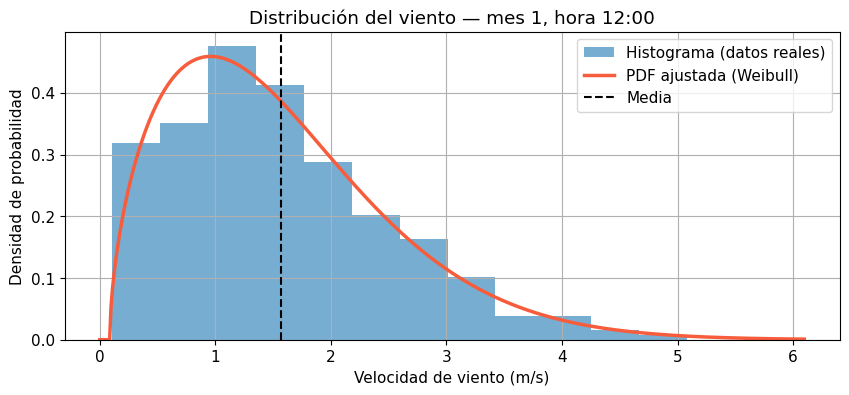

In [27]:
# loc=0 porque el viento no puede ser negativo (así se lo indicamos al algoritmo de ajuste)
parametros = stats.weibull_min.fit(datos_grupo, loc=0)
dist = stats.weibull_min(*parametros)

media_dist, std_dist = dist.mean(), dist.std()
print(f"Parámetros ajustados -> forma: {parametros[0]:.2f}, ubicación: {parametros[1]:.2f}, escala: {parametros[2]:.2f}")
print(f"Media de la distribución ajustada: {media_dist:.2f} m/s")
print(f"Desv. estándar de la distribución ajustada: {std_dist:.2f} m/s")

x = np.linspace(0, datos_grupo.max() * 1.2, 500)
pdf_valores = dist.pdf(x)

plt.hist(datos_grupo, bins=12, density=True, alpha=0.6, label="Histograma (datos reales)")
plt.plot(x, pdf_valores, linewidth=2.5, color="#F75D3C", label="PDF ajustada (Weibull)")
plt.axvline(media_dist, color="black", linestyle="--", label="Media")
plt.title(f"Distribución del viento — mes {mes_ejemplo}, hora {hora_ejemplo}:00")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.show()


### 5.5 ¿Y si comparamos varias familias de distribuciones a la vez?

La Weibull no es la única opción para variables no-negativas. Ajustemos también **Rayleigh**,
**Gamma** y **Lognormal** a los mismos datos, y comparemos visualmente cuál se ajusta mejor.


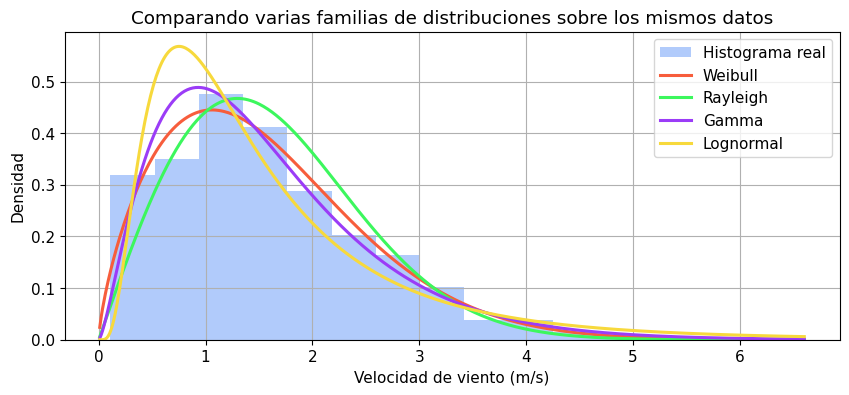

Error promedio de cada familia respecto al histograma (menor = mejor ajuste):
  Weibull   : 0.00081
  Gamma     : 0.00162
  Rayleigh  : 0.00260
  Lognormal : 0.00533


In [12]:
familias = {
    "Weibull":   stats.weibull_min,
    "Rayleigh":  stats.rayleigh,
    "Gamma":     stats.gamma,
    "Lognormal": stats.lognorm,
}

colores_familias = {"Weibull": "#F75D3C", "Rayleigh": "#3CF75D", "Gamma": "#9B3CF7", "Lognormal": "#F7D93C"}

plt.hist(datos_grupo, bins=12, density=True, color="#3C7DF7", alpha=0.4, label="Histograma real")

x_comp = np.linspace(0.01, datos_grupo.max() * 1.3, 500)
errores_ajuste = {}
for nombre, familia in familias.items():
    params_familia = familia.fit(datos_grupo, floc=0)
    pdf_familia = familia.pdf(x_comp, *params_familia)
    plt.plot(x_comp, pdf_familia, linewidth=2.2, color=colores_familias[nombre], label=nombre)

    # Un indicador simple de qué tan lejos está la curva del histograma real
    hist_vals, hist_bins = np.histogram(datos_grupo, bins=12, density=True)
    centros_bins = (hist_bins[:-1] + hist_bins[1:]) / 2
    pdf_en_centros = familia.pdf(centros_bins, *params_familia)
    errores_ajuste[nombre] = np.mean((hist_vals - pdf_en_centros) ** 2)

plt.title("Comparando varias familias de distribuciones sobre los mismos datos")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

print("Error promedio de cada familia respecto al histograma (menor = mejor ajuste):")
for nombre, error in sorted(errores_ajuste.items(), key=lambda kv: kv[1]):
    print(f"  {nombre:10s}: {error:.5f}")


Todas estas familias son razonables candidatas (todas son positivas y asimétricas),
pero la **Weibull es el estándar de la industria eólica** porque, además de ajustarse bien,
tiene una interpretación física clara de sus parámetros (forma y escala) directamente ligada
al comportamiento del viento. Por eso es la que usaremos de aquí en adelante — igual que en
el código original de la tesis.

### 5.6 La CDF de nuestra distribución ajustada

Ya vimos en la sección 1 que la CDF nos da probabilidades acumuladas directamente. Grafiquemos
la CDF de la Weibull que ajustamos para este grupo (enero, mediodía).


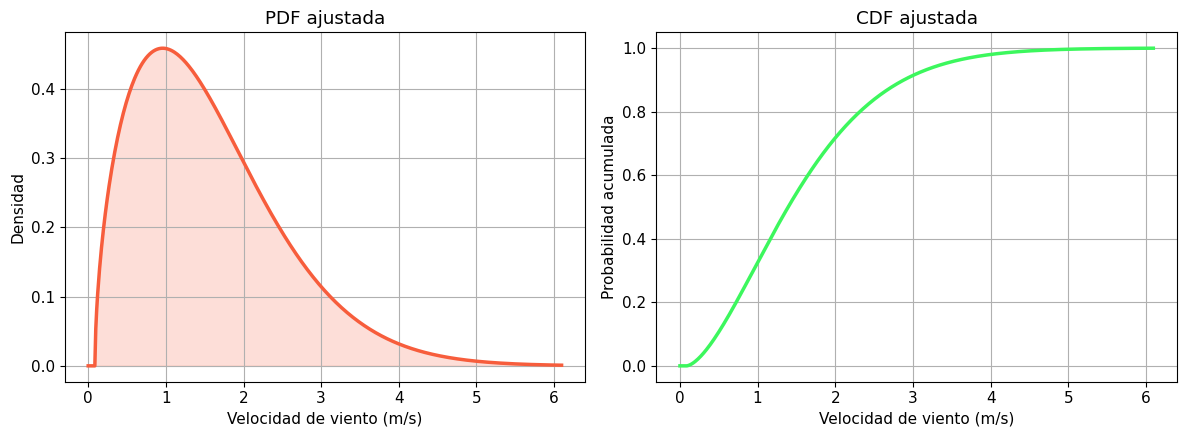

In [29]:
cdf_valores = dist.cdf(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(x, pdf_valores, color="#F75D3C", linewidth=2.5)
axes[0].fill_between(x, pdf_valores, color="#F75D3C", alpha=0.2)
axes[0].set_title("PDF ajustada")
axes[0].set_xlabel("Velocidad de viento (m/s)")
axes[0].set_ylabel("Densidad")

axes[1].plot(x, cdf_valores, color="#3CF75D", linewidth=2.5)
axes[1].set_title("CDF ajustada")
axes[1].set_xlabel("Velocidad de viento (m/s)")
axes[1].set_ylabel("Probabilidad acumulada")

plt.tight_layout()
plt.show()


## 6. La idea clave: usar media ± desviación estándar para definir escenarios

Aquí es donde la estadística básica se vuelve una herramienta de ingeniería.

En estudios de energía renovable es muy común no trabajar con "el" valor promedio del viento,
sino con **tres escenarios representativos**:

- 🔴 **Escenario malo**: viento bajo (mala generación).
- 🟡 **Escenario medio**: viento cercano al promedio.
- 🟢 **Escenario bueno**: viento alto (buena generación).

¿Cómo definimos los límites entre "malo", "medio" y "bueno"? Con algo que ya conocemos —y que
vimos con la Normal en la sección 1— la **regla empírica de la media y la desviación
estándar**:

$$
\text{malo}: X \le \mu - \sigma \qquad
\text{medio}: \mu - \sigma < X < \mu + \sigma \qquad
\text{bueno}: X \ge \mu + \sigma
$$

Con la PDF ajustada, calculamos la **probabilidad** de cada escenario usando la CDF (igual que
en la sección 1.5).


Umbral bajo (media - std):  0.61 m/s
Umbral alto (media + std):  2.53 m/s
P(escenario malo)  = 14.98%
P(escenario medio) = 69.38%
P(escenario bueno) = 15.64%


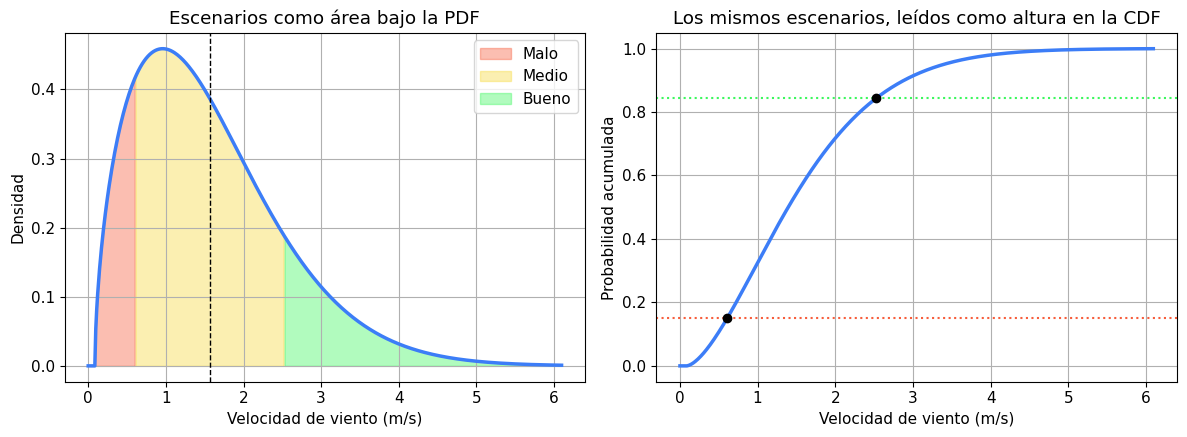

In [30]:
umbral_bajo = media_dist - std_dist
umbral_alto = media_dist + std_dist

prob_malo = dist.cdf(umbral_bajo)
prob_bueno = 1 - dist.cdf(umbral_alto)
prob_medio = 1 - prob_malo - prob_bueno

print(f"Umbral bajo (media - std):  {umbral_bajo:.2f} m/s")
print(f"Umbral alto (media + std):  {umbral_alto:.2f} m/s")
print(f"P(escenario malo)  = {prob_malo:.2%}")
print(f"P(escenario medio) = {prob_medio:.2%}")
print(f"P(escenario bueno) = {prob_bueno:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x, pdf_valores, linewidth=2.5, color="#3C7DF7")
axes[0].fill_between(x, pdf_valores, where=(x <= umbral_bajo), color="#F75D3C", alpha=0.4, label="Malo")
axes[0].fill_between(x, pdf_valores, where=(x > umbral_bajo) & (x < umbral_alto), color="#F7D93C", alpha=0.4, label="Medio")
axes[0].fill_between(x, pdf_valores, where=(x >= umbral_alto), color="#3CF75D", alpha=0.4, label="Bueno")
axes[0].axvline(media_dist, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Escenarios como área bajo la PDF")
axes[0].set_xlabel("Velocidad de viento (m/s)")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].plot(x, cdf_valores, linewidth=2.5, color="#3C7DF7")
axes[1].scatter([umbral_bajo, umbral_alto], [prob_malo, dist.cdf(umbral_alto)], color="black", zorder=5)
axes[1].axhline(prob_malo, color="#F75D3C", linestyle=":", linewidth=1.5)
axes[1].axhline(dist.cdf(umbral_alto), color="#3CF75D", linestyle=":", linewidth=1.5)
axes[1].set_title("Los mismos escenarios, leídos como altura en la CDF")
axes[1].set_xlabel("Velocidad de viento (m/s)")
axes[1].set_ylabel("Probabilidad acumulada")

plt.tight_layout()
plt.show()


La gráfica de la derecha muestra exactamente la conexión que vimos en la sección 1.5:
la probabilidad del escenario "malo" (área sombreada roja, izquierda) es la misma que la
**altura** de la CDF en el umbral bajo. No es una coincidencia — es, literalmente, la
definición de la CDF.


## 7. De probabilidades a valores concretos: simulación de Montecarlo

Saber que "hay cierta probabilidad de un escenario malo" es útil, pero para **simular** un año
completo necesitamos números concretos de velocidad de viento para cada escenario, no solo la
probabilidad.

La solución: le pedimos a la distribución ajustada que genere **muestras aleatorias**
(`dist.rvs`, de *random variates*) — literalmente "pedirle a la fórmula matemática que nos
regale números que se comporten como el viento real". Luego clasificamos esos números según
los mismos umbrales de la sección anterior.

Antes de hacerlo con muchas muestras, comprobemos —igual que en la sección 1.3— que entre más
muestras generamos, más se parece el histograma de las muestras a la curva PDF original.


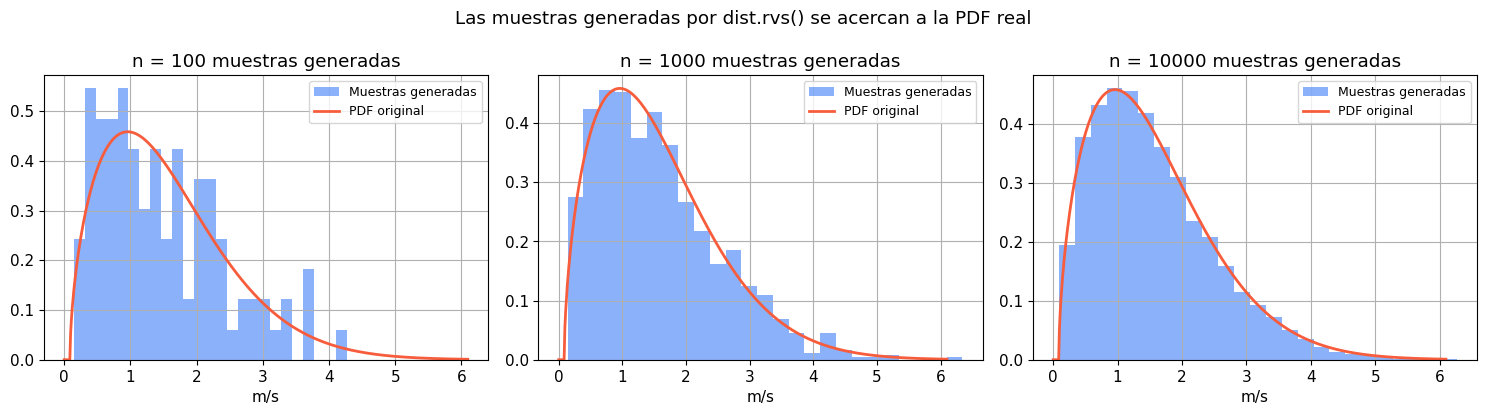

In [31]:
tamaños_montecarlo = [100, 1000, 10000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, n in zip(axes, tamaños_montecarlo):
    muestras_n = dist.rvs(size=n)
    ax.hist(muestras_n, bins=25, density=True, color="#3C7DF7", alpha=0.6, label="Muestras generadas")
    ax.plot(x, pdf_valores, color="#F75D3C", linewidth=2, label="PDF original")
    ax.set_title(f"n = {n} muestras generadas")
    ax.set_xlabel("m/s")
    ax.legend(fontsize=9)
plt.suptitle("Las muestras generadas por dist.rvs() se acercan a la PDF real")
plt.tight_layout()
plt.show()


Con 10,000 muestras el parecido es prácticamente perfecto — por eso el código que
construimos más adelante siempre genera lotes de 10,000 valores: es un número lo bastante
grande para que la clasificación en malo/medio/bueno sea confiable.


De 10,000 muestras generadas:
   1458 caen en 'malo'  -> ej: [0.49 0.27 0.22 0.23 0.24]
   6913 caen en 'medio' -> ej: [0.88 2.18 1.08 2.06 2.27]
   1629 caen en 'bueno' -> ej: [2.71 2.72 3.14 2.57 2.89]


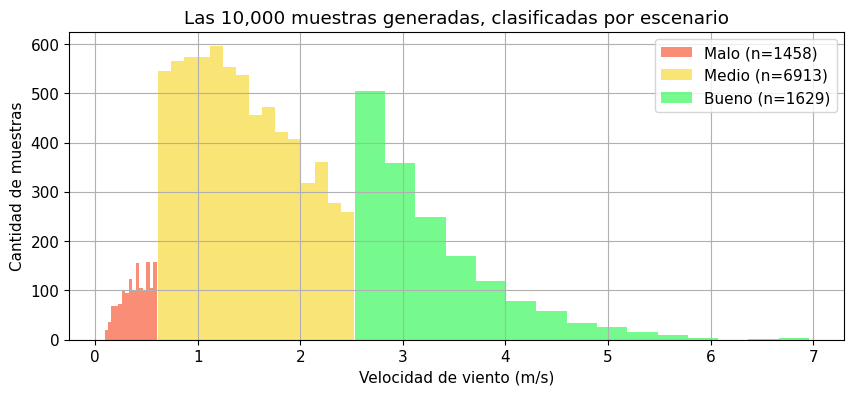

In [32]:
muestras = np.round(dist.rvs(size=10_000), 2)

muestras_malo = muestras[(muestras <= umbral_bajo) & (muestras > 0)]
muestras_medio = muestras[(muestras > umbral_bajo) & (muestras < umbral_alto)]
muestras_bueno = muestras[(muestras >= umbral_alto)]

print(f"De 10,000 muestras generadas:")
print(f"  {len(muestras_malo):5d} caen en 'malo'  -> ej: {muestras_malo[:5]}")
print(f"  {len(muestras_medio):5d} caen en 'medio' -> ej: {muestras_medio[:5]}")
print(f"  {len(muestras_bueno):5d} caen en 'bueno' -> ej: {muestras_bueno[:5]}")

plt.hist(muestras_malo, bins=15, color="#F75D3C", alpha=0.7, label=f"Malo (n={len(muestras_malo)})")
plt.hist(muestras_medio, bins=15, color="#F7D93C", alpha=0.7, label=f"Medio (n={len(muestras_medio)})")
plt.hist(muestras_bueno, bins=15, color="#3CF75D", alpha=0.7, label=f"Bueno (n={len(muestras_bueno)})")
plt.title("Las 10,000 muestras generadas, clasificadas por escenario")
plt.xlabel("Velocidad de viento (m/s)")
plt.ylabel("Cantidad de muestras")
plt.legend()
plt.show()


Con esto ya tenemos, para **un solo grupo** (enero a las 12:00), un banco de valores
representativos de viento malo/medio/bueno. El paso final es simplemente **repetir este
proceso para cada una de las 288 combinaciones de mes y hora**, y ensamblar todo en una tabla
ordenada. Eso es exactamente lo que hace la función siguiente.


## 8. Ensamblando todo en una función

Ahora que entendemos cada pieza, la función completa ya no es "código abstracto": es
simplemente **repetir 288 veces (12 meses × 24 horas)** los pasos que acabamos de hacer a mano:

1. Tomar los datos históricos de ese mes/hora.
2. Ajustar una Weibull (sección 5).
3. Calcular media, desviación estándar y umbrales (sección 6).
4. Generar muestras aleatorias y clasificarlas en malo/medio/bueno (sección 7).
5. Guardar la cantidad de valores que necesitamos (tantos como horas tenga ese mes/hora en el
   rango de fechas de un año).

La única parte "nueva" es un pequeño mecanismo de seguridad: si por mala suerte no generamos
suficientes muestras en algún escenario, simplemente generamos otro lote de 10,000 y volvemos
a intentar.


In [33]:
def generar_escenarios_viento(df, columna, seed=None):
    """
    Genera escenarios malo/medio/bueno de velocidad de viento para cada
    hora de un año típico (8760 horas), a partir de datos históricos.
    """
    if seed is not None:
        np.random.seed(seed)

    fechas = pd.date_range(start="2019-01-01 00:00", end="2019-12-31 23:00", freq="1h")

    df_escenarios = pd.DataFrame({"hour": fechas.hour, "month": fechas.month})
    for etiqueta in ["bad", "mean", "good"]:
        df_escenarios[etiqueta] = np.nan

    probabilidades = {"bad": [], "mean": [], "good": []}

    for mes in range(1, 13):
        for hora in range(0, 24):

            datos = df.loc[(df.Hour == hora) & (df.Month == mes), columna].to_numpy()
            num_horas_necesarias = np.sum((fechas.month == mes) & (fechas.hour == hora))

            params = stats.weibull_min.fit(datos, loc=0)
            dist_local = stats.weibull_min(*params)
            media_local, std_local = dist_local.mean(), dist_local.std()

            umbral_bajo = media_local - std_local
            umbral_alto = media_local + std_local

            probabilidades["bad"].append(dist_local.cdf(umbral_bajo))
            probabilidades["mean"].append(dist_local.cdf(umbral_alto) - probabilidades["bad"][-1])
            probabilidades["good"].append(1 - probabilidades["bad"][-1] - probabilidades["mean"][-1])

            valores_escenario = {}
            intentos = 0
            while True:
                muestras = np.round(dist_local.rvs(size=10_000), 2)

                valores_escenario["bad"] = muestras[(muestras <= umbral_bajo) & (muestras > 0)]
                valores_escenario["mean"] = muestras[(muestras > umbral_bajo) & (muestras < umbral_alto)]
                valores_escenario["good"] = muestras[muestras >= umbral_alto]

                suficientes = all(len(valores_escenario[k]) >= num_horas_necesarias for k in valores_escenario)
                if suficientes:
                    break
                intentos += 1
                if intentos > 200:
                    # Muy improbable, pero por seguridad usamos los datos históricos tal cual
                    for k in valores_escenario:
                        valores_escenario[k] = datos
                    break

            mascara = (df_escenarios["hour"] == hora) & (df_escenarios["month"] == mes)
            for etiqueta in ["bad", "mean", "good"]:
                df_escenarios.loc[mascara, etiqueta] = valores_escenario[etiqueta][:num_horas_necesarias]

    probabilidades = {k: float(np.mean(v)) for k, v in probabilidades.items()}
    return df_escenarios, probabilidades


In [34]:
df_escenarios, prob_promedio = generar_escenarios_viento(df, "WindSpeed", seed=42)

print("Probabilidad promedio de cada escenario a lo largo del año:")
for k, v in prob_promedio.items():
    print(f"  {k:5s}: {v:.2%}")

print()
print(df_escenarios.head().to_string())


Probabilidad promedio de cada escenario a lo largo del año:
  bad  : 16.35%
  mean : 67.44%
  good : 16.22%

   hour  month   bad  mean  good
0     0      1  0.47  0.68  1.52
1     1      1  0.33  0.69  1.25
2     2      1  0.46  1.04  1.56
3     3      1  0.29  0.96  1.60
4     4      1  0.40  0.65  1.40


## 9. Radiografía completa: la PDF de cada hora del día

Ya vimos en detalle la distribución de **un solo grupo** (enero, mediodía). Pero dijimos que
en realidad estamos ajustando **288 distribuciones distintas** (una por cada mes-hora). Para
que esto deje de sentirse abstracto, grafiquemos **las 24 distribuciones de un mismo mes**
(una por cada hora del día), resaltando en rojo la que ya conocemos (mediodía).


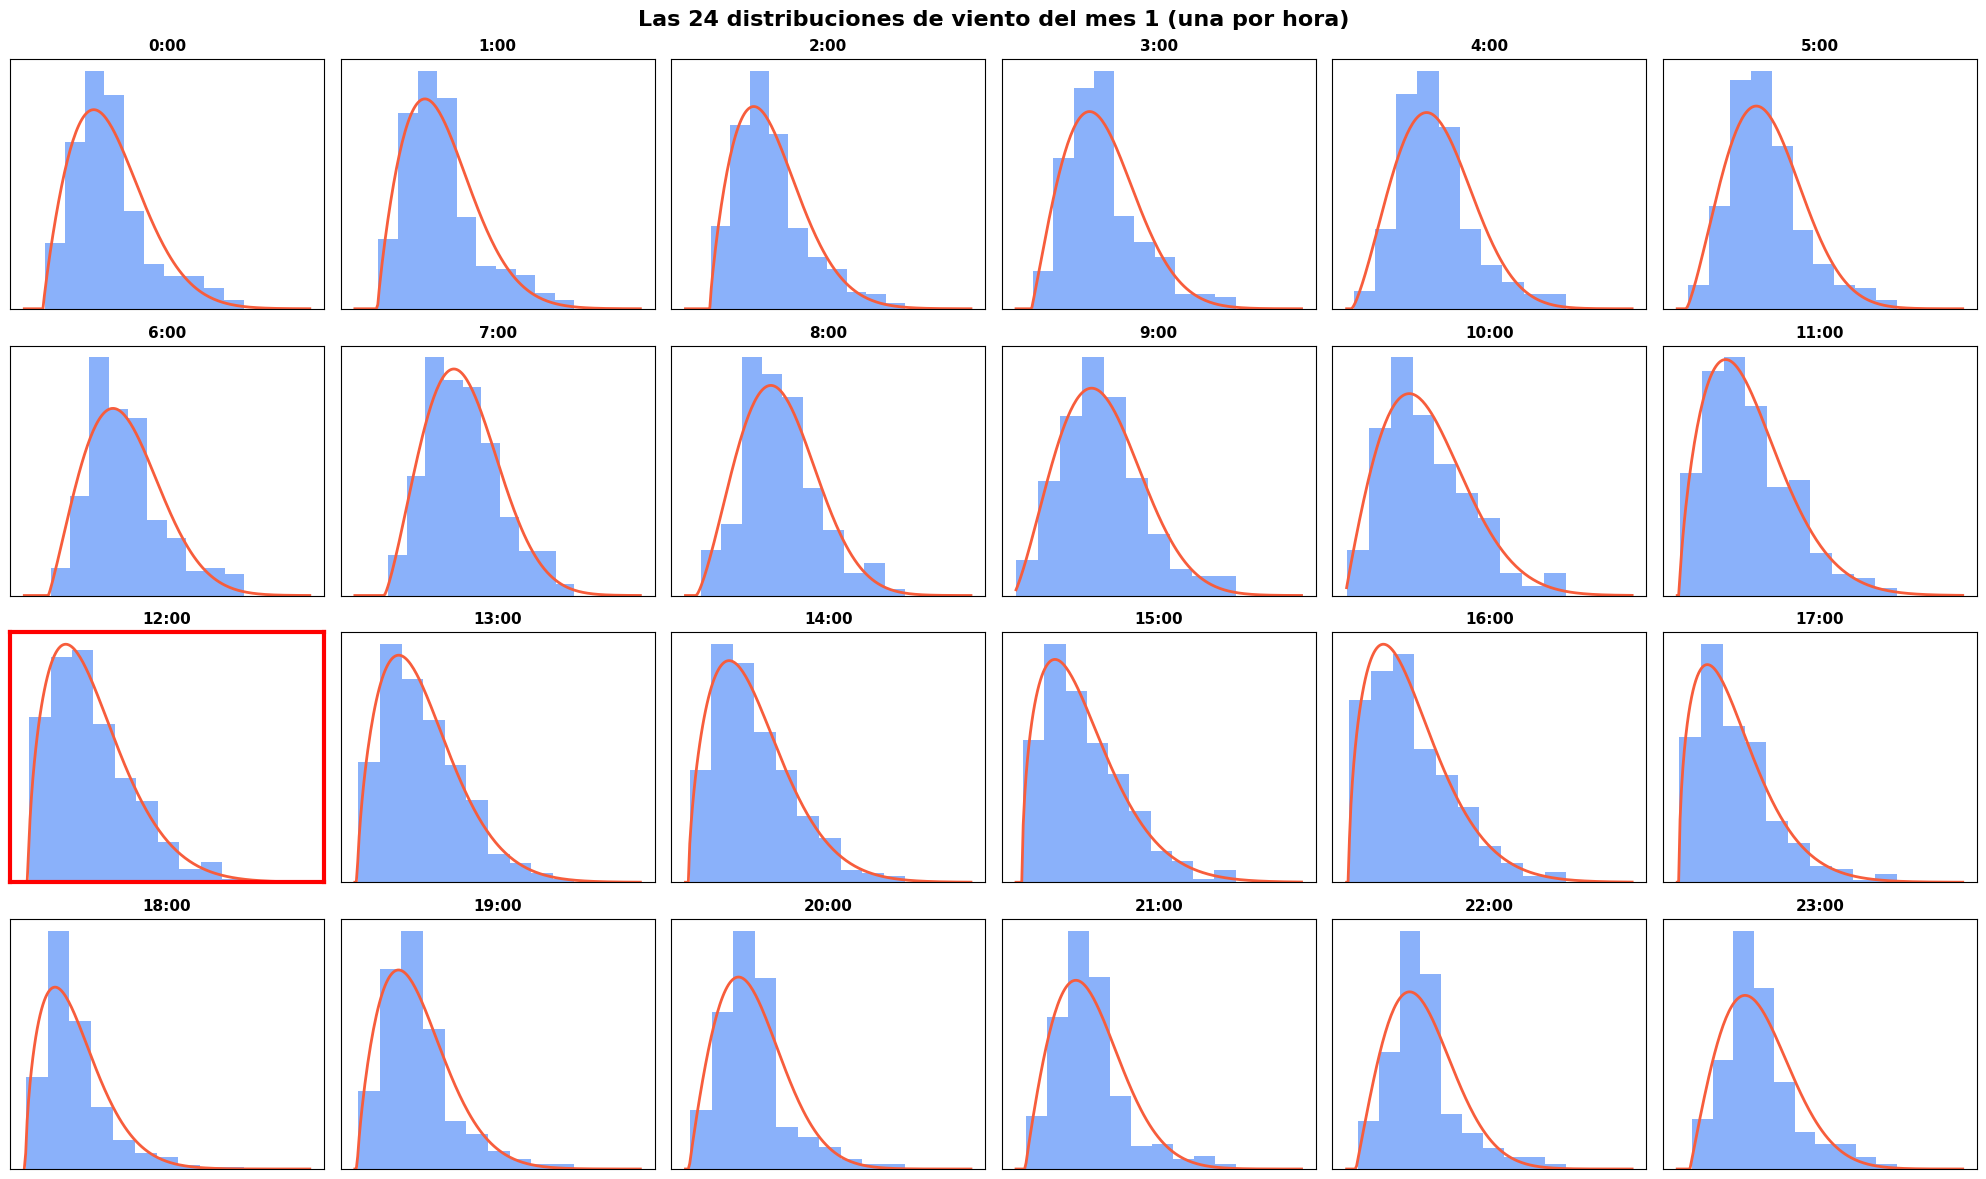

In [35]:
mes_galeria = 1  # enero

fig, axes = plt.subplots(4, 6, figsize=(20, 12))
axes = axes.flatten()

for hora_g in range(24):
    ax = axes[hora_g]
    datos_hg = df.loc[(df.Month == mes_galeria) & (df.Hour == hora_g), col].to_numpy()

    ax.hist(datos_hg, bins=10, density=True, color="#3C7DF7", alpha=0.6)

    params_hg = stats.weibull_min.fit(datos_hg, loc=0)
    dist_hg = stats.weibull_min(*params_hg)
    x_hg = np.linspace(0, max(datos_hg.max(), 1) * 1.3, 200)
    ax.plot(x_hg, dist_hg.pdf(x_hg), color="#F75D3C", linewidth=2)

    ax.set_title(f"{hora_g}:00", fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

    if hora_g == hora_ejemplo:
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

plt.suptitle(f"Las 24 distribuciones de viento del mes {mes_galeria} (una por hora)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Nota cómo la forma de la distribución **cambia poco a poco** a lo largo del día,
siguiendo el patrón diario que vimos en la sección 4 (más viento en la tarde, menos en la
madrugada). El recuadro rojo es justo el grupo que analizamos a fondo en la sección 5.

Hagamos el ejercicio complementario: fijemos una hora (mediodía) y veamos cómo cambia la
distribución **mes a mes**, para ver el patrón estacional.


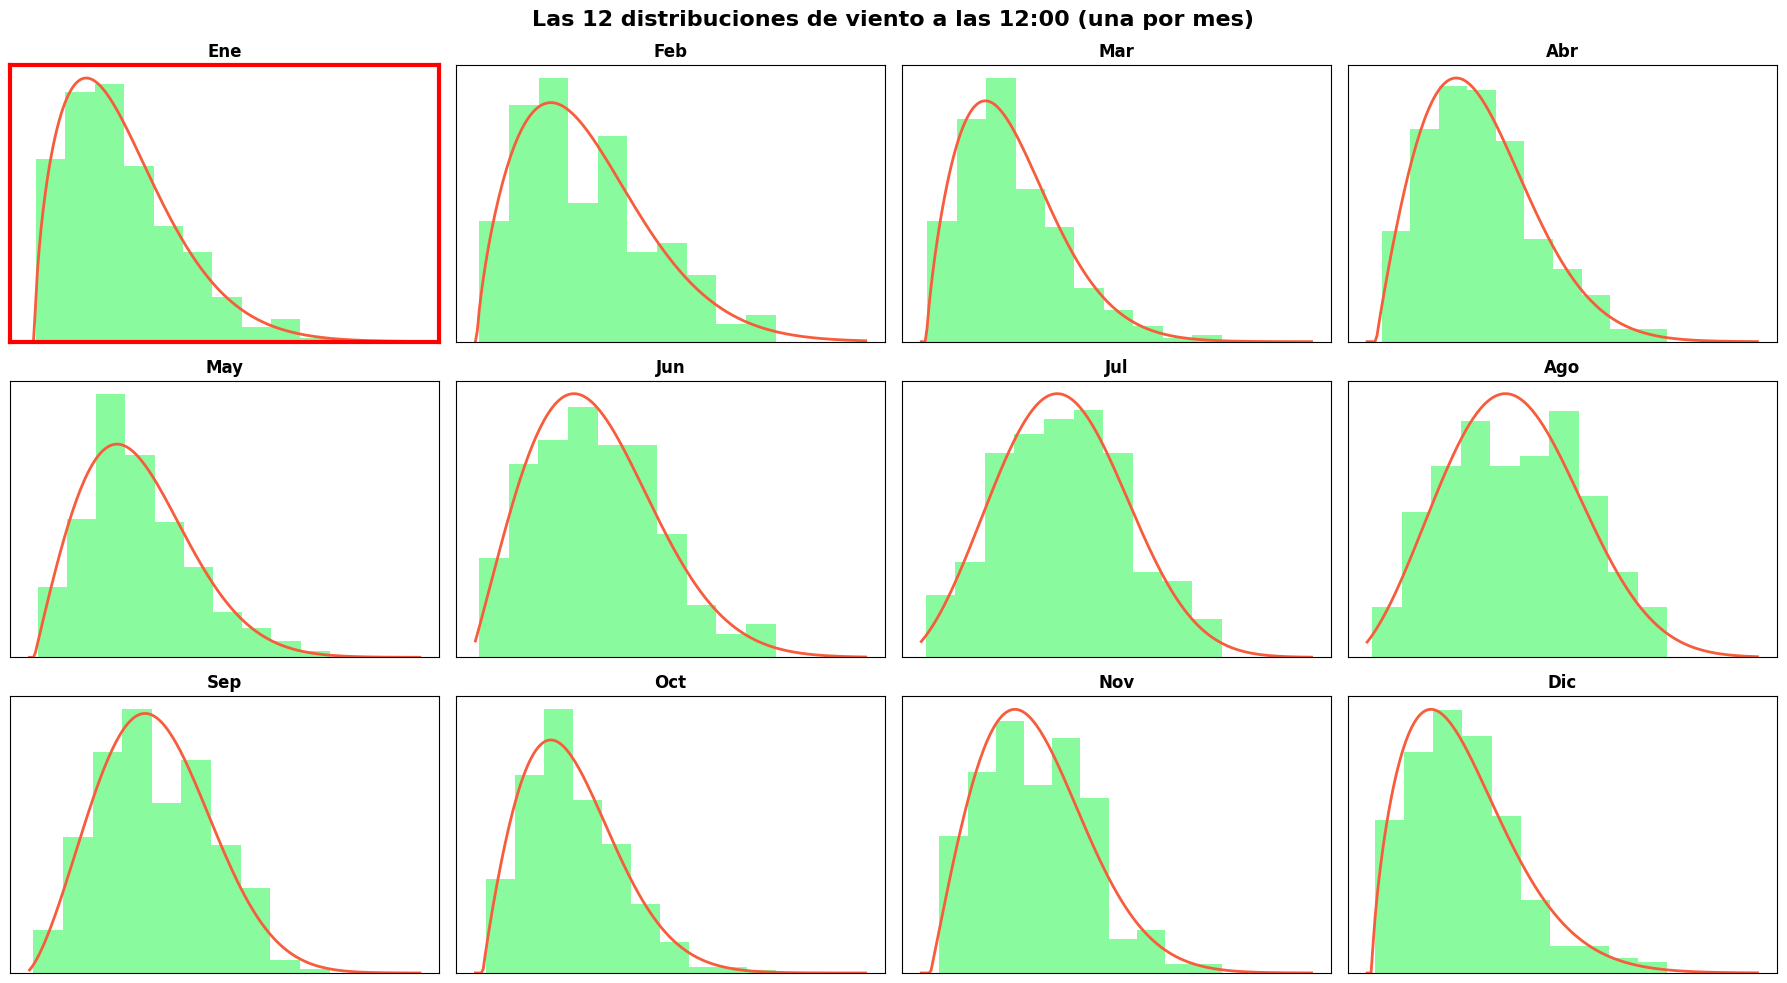

In [36]:
hora_galeria = 12  # mediodía

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

nombres_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for mes_g in range(1, 13):
    ax = axes[mes_g - 1]
    datos_mg = df.loc[(df.Month == mes_g) & (df.Hour == hora_galeria), col].to_numpy()

    ax.hist(datos_mg, bins=10, density=True, color="#3CF75D", alpha=0.6)

    params_mg = stats.weibull_min.fit(datos_mg, loc=0)
    dist_mg = stats.weibull_min(*params_mg)
    x_mg = np.linspace(0, max(datos_mg.max(), 1) * 1.3, 200)
    ax.plot(x_mg, dist_mg.pdf(x_mg), color="#F75D3C", linewidth=2)

    ax.set_title(nombres_meses[mes_g - 1], fontsize=12, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

    if mes_g == mes_ejemplo:
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

plt.suptitle(f"Las 12 distribuciones de viento a las {hora_galeria}:00 (una por mes)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Con estas dos galerías queda muy claro por qué la función de la sección 8 necesita un
doble ciclo (`for mes ... for hora ...`): literalmente está repitiendo el proceso de ajuste
que acabamos de visualizar, 288 veces, una por cada mini-gráfica que podríamos dibujar.


## 10. Visualizando el resultado final: un "gemelo estadístico" del viento

Comparemos, para un mes específico (enero), el viento **real (simulado por nosotros al
inicio)** contra los tres escenarios que acabamos de construir.


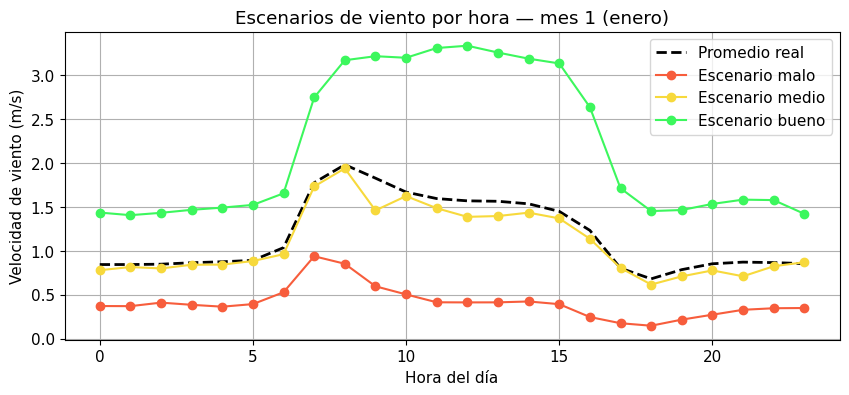

In [37]:
mes_vista = 1
horas_mes = np.arange(24)

real_por_hora = df.loc[df.Month == mes_vista].groupby("Hour")["WindSpeed"].mean()
malo_por_hora = df_escenarios.loc[df_escenarios.month == mes_vista].groupby("hour")["bad"].mean()
medio_por_hora = df_escenarios.loc[df_escenarios.month == mes_vista].groupby("hour")["mean"].mean()
bueno_por_hora = df_escenarios.loc[df_escenarios.month == mes_vista].groupby("hour")["good"].mean()

plt.plot(horas_mes, real_por_hora.values, "k--", linewidth=2, label="Promedio real")
plt.plot(horas_mes, malo_por_hora.values, color="#F75D3C", marker="o", label="Escenario malo")
plt.plot(horas_mes, medio_por_hora.values, color="#F7D93C", marker="o", label="Escenario medio")
plt.plot(horas_mes, bueno_por_hora.values, color="#3CF75D", marker="o", label="Escenario bueno")

plt.title(f"Escenarios de viento por hora — mes {mes_vista} (enero)")
plt.xlabel("Hora del día")
plt.ylabel("Velocidad de viento (m/s)")
plt.legend()
plt.show()


Por último, veamos cómo varía la **probabilidad del escenario malo** a lo largo de todo
el año (mes × hora), con el mismo tipo de mapa de calor que usamos en la sección 4.


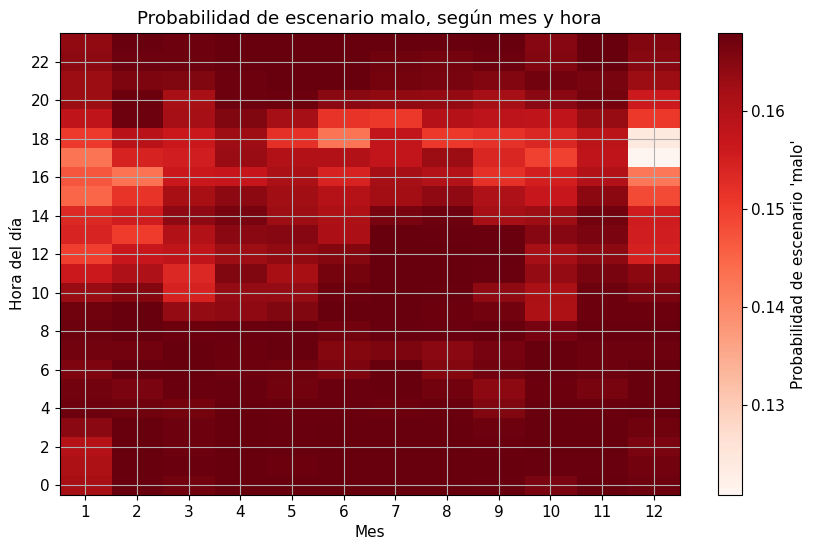

In [38]:
matriz_prob_malo = np.zeros((24, 12))

for mes_p in range(1, 13):
    for hora_p in range(24):
        datos_p = df.loc[(df.Month == mes_p) & (df.Hour == hora_p), col].to_numpy()
        params_p = stats.weibull_min.fit(datos_p, loc=0)
        dist_p = stats.weibull_min(*params_p)
        umbral_p = dist_p.mean() - dist_p.std()
        matriz_prob_malo[hora_p, mes_p - 1] = dist_p.cdf(umbral_p)

plt.figure(figsize=(10, 6))
plt.imshow(matriz_prob_malo, aspect="auto", cmap="Reds", origin="lower")
plt.colorbar(label="Probabilidad de escenario 'malo'")
plt.title("Probabilidad de escenario malo, según mes y hora")
plt.xlabel("Mes")
plt.ylabel("Hora del día")
plt.xticks(ticks=range(12), labels=range(1, 13))
plt.yticks(ticks=range(0, 24, 2), labels=range(0, 24, 2))
plt.show()


Este mapa de calor es, en el fondo, un resumen visual de **las 288 distribuciones**
que ajustamos: en las zonas más rojas (por ejemplo, la madrugada en mitad de año) el
escenario "malo" es más probable, mientras que en las zonas más claras (tardes de enero) casi
nunca ocurre.


## 11. Lo que acabamos de hacer (y por qué importa)

Empezamos con la pregunta más simple de la estadística —"¿cuál es la media?"— y terminamos
con una función capaz de simular un año completo de escenarios de viento para un estudio de
energía renovable, ajustando y visualizando 288 distribuciones de probabilidad distintas en el
camino. En el recorrido usamos:

| Concepto estadístico                    | Para qué lo usamos aquí                                     |
|-------------------------------------------|----------------------------------------------------------------|
| Variable aleatoria (discreta/continua)  | Entender qué significa "azar" con el ejemplo del dado         |
| Histograma y número de bins             | Ver cómo se construye visualmente una distribución            |
| Ley de los grandes números              | Entender por qué más datos = mejor aproximación a la "verdad" |
| PDF (función de densidad)               | Modelar matemáticamente el viento en vez de solo un histograma |
| CDF (función acumulada)                 | Calcular probabilidades exactas de rangos de valores           |
| Percentiles                              | Leer la CDF "al revés" (de probabilidad a valor)               |
| Media, mediana, desviación estándar     | Describir el viento en general                                  |
| `groupby` / estadística condicionada    | Descubrir que el viento cambia por hora y por mes               |
| Boxplots y heatmaps                     | Visualizar dispersión y patrones en dos dimensiones a la vez     |
| Parámetros de forma y escala (Weibull)  | Entender qué controla la forma de una distribución               |
| Ajuste por máxima verosimilitud (`fit`) | Encontrar automáticamente los mejores parámetros                 |
| Comparación de familias de distribución | Justificar por qué se usa Weibull y no otra familia              |
| Media ± desviación estándar como umbral | Definir escenarios malo/medio/bueno de forma objetiva            |
| Números aleatorios (`rvs`, Montecarlo)  | Generar valores concretos y simulables para cada escenario       |

**Ejercicios para profundizar:**

1. Repite todo el proceso para una columna de **irradiancia solar** en vez de viento (pista:
   la irradiancia suele modelarse mejor con una distribución **Beta** o **Gamma** en vez de
   Weibull, y es cero en las horas de noche).
2. Cambia el umbral de "malo/bueno" de ±1 desviación estándar a ±0.5 o a percentiles fijos
   (por ejemplo, percentil 20 y percentil 80) y compara cómo cambian las probabilidades.
3. En la sección 5.5 comparamos familias de distribución con un indicador simple de error.
   Investiga la prueba de bondad de ajuste **Kolmogorov-Smirnov** (`scipy.stats.kstest`) y
   úsala para comparar las mismas familias de forma más rigurosa.
4. **Bonus — otro tipo de "escenario":** en estudios de confiabilidad eléctrica también se
   generan escenarios, pero de *disponibilidad* de la red (si hubo o no interrupciones de
   servicio). Ahí la variable no es continua como el viento, sino más parecida a una moneda:
   "¿hubo apagón esa hora o no?", y se usan los indicadores **SAIFI** (frecuencia de fallas) y
   **SAIDI** (duración promedio de las fallas), modelando el número de eventos con una
   distribución normal en vez de una Weibull. La lógica de fondo —media, desviación estándar,
   generación aleatoria— es la misma que acabamos de construir aquí.
